In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import sys
sys.path.append('../')
from src.config import DATA_RAW, FIGURES, TARGET_COL

# Reproducibility
np.random.seed(42)
plt.style.use('seaborn-v0_8-whitegrid')

# ── 1. Load

In [6]:
df = pd.read_csv(DATA_RAW/"train.csv")
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18  OverallCond    1460

total na count

In [19]:
df.isna().sum().sum()

np.int64(7829)

In [20]:
df.dtypes.value_counts()

str        43
int64      35
float64     3
Name: count, dtype: int64

In [21]:
df.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


In [24]:
missing = df.isnull().mean().sort_values(ascending=False)
missing = missing[missing > 0]
print(missing)   # some cols have 99% missing!

PoolQC          0.995205
MiscFeature     0.963014
Alley           0.937671
Fence           0.807534
MasVnrType      0.597260
FireplaceQu     0.472603
LotFrontage     0.177397
GarageQual      0.055479
GarageFinish    0.055479
GarageType      0.055479
GarageYrBlt     0.055479
GarageCond      0.055479
BsmtFinType2    0.026027
BsmtExposure    0.026027
BsmtCond        0.025342
BsmtQual        0.025342
BsmtFinType1    0.025342
MasVnrArea      0.005479
Electrical      0.000685
dtype: float64


In [25]:
print(f"Target skewness: {df[TARGET_COL].skew():.3f}")

Target skewness: 1.883


In [45]:
for col in df.columns:
  if len(df[col].unique()) < 20:
    print(f"{col}: {df[col].unique()}")
    print(f"{col}: {df[col].isna().sum()}")
    print()

# df['GarageType'].unique()

MSSubClass: [ 60  20  70  50 190  45  90 120  30  85  80 160  75 180  40]
MSSubClass: 0

MSZoning: <StringArray>
['RL', 'RM', 'C (all)', 'FV', 'RH']
Length: 5, dtype: str
MSZoning: 0

Street: <StringArray>
['Pave', 'Grvl']
Length: 2, dtype: str
Street: 0

Alley: <StringArray>
[nan, 'Grvl', 'Pave']
Length: 3, dtype: str
Alley: 1369

LotShape: <StringArray>
['Reg', 'IR1', 'IR2', 'IR3']
Length: 4, dtype: str
LotShape: 0

LandContour: <StringArray>
['Lvl', 'Bnk', 'Low', 'HLS']
Length: 4, dtype: str
LandContour: 0

Utilities: <StringArray>
['AllPub', 'NoSeWa']
Length: 2, dtype: str
Utilities: 0

LotConfig: <StringArray>
['Inside', 'FR2', 'Corner', 'CulDSac', 'FR3']
Length: 5, dtype: str
LotConfig: 0

LandSlope: <StringArray>
['Gtl', 'Mod', 'Sev']
Length: 3, dtype: str
LandSlope: 0

Condition1: <StringArray>
['Norm', 'Feedr', 'PosN', 'Artery', 'RRAe', 'RRNn', 'RRAn', 'PosA', 'RRNe']
Length: 9, dtype: str
Condition1: 0

Condition2: <StringArray>
['Norm', 'Artery', 'RRNn', 'Feedr', 'PosN', 'Po

### ── Target distribution (before & after log) ───────────

In [46]:
import scipy.stats as stats

C:\Users\Admin\AppData\Local\Temp\ipykernel_2432\3413382291.py:8: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Arial.
  plt.savefig(FIGURES / 'target_distribution.png', dpi=150, bbox_inches='tight')
d:\AI Eng\ML\Linear Regression\Projects\01_House Price Predictor\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


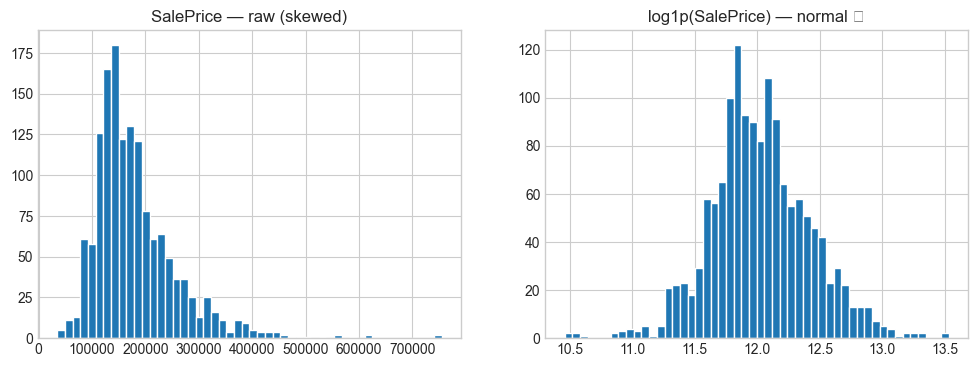

In [48]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df['SalePrice'], bins=50, edgecolor='white')
axes[0].set_title('SalePrice — raw (skewed)')

axes[1].hist(np.log1p(df['SalePrice']), bins=50, edgecolor='white')
axes[1].set_title('log1p(SalePrice) — normal ✓')
plt.savefig(FIGURES / 'target_distribution.png', dpi=150, bbox_inches='tight')


### ── Top 10 correlations with target ────────────────────

In [ ]:
numeric_cols = df.select_dtypes(include=np.number).columns
corr = df[numeric_cols].corr()['SalePrice'].abs()
top19 = corr.sort_values(ascending=False)[1:19]
print(top19)

OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
YearRemodAdd    0.507101
GarageYrBlt     0.486362
MasVnrArea      0.477493
Fireplaces      0.466929
BsmtFinSF1      0.386420
LotFrontage     0.351799
WoodDeckSF      0.324413
2ndFlrSF        0.319334
OpenPorchSF     0.315856
Name: SalePrice, dtype: float64


### ── Scatter: GrLivArea vs SalePrice ────────────────────

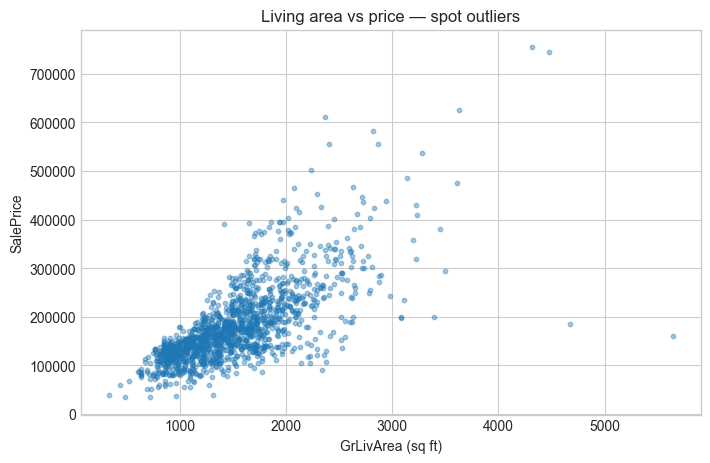

In [54]:
plt.figure(figsize=(8, 5))
plt.scatter(df['GrLivArea'], df['SalePrice'], alpha=0.4, s=10)
plt.xlabel('GrLivArea (sq ft)')
plt.ylabel('SalePrice')
plt.title('Living area vs price — spot outliers')
# Two outliers: huge area, very low price → partial sales
plt.savefig(FIGURES / 'grlivarea_vs_price.png', dpi=150)

### ── Correlation heatmap (top 19 features) ──────────────

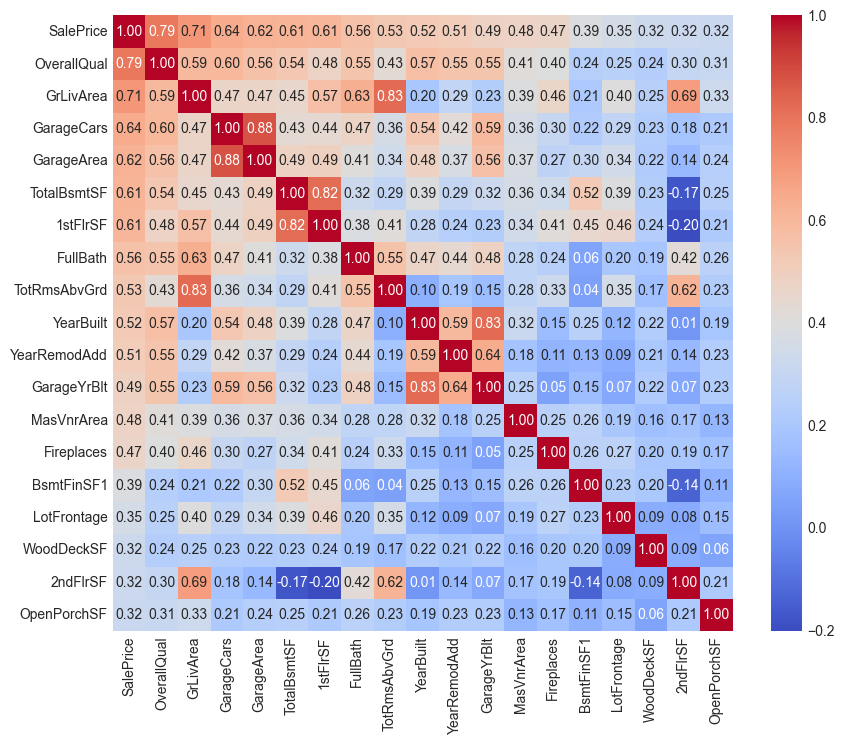

In [56]:
top19 = corr.sort_values(ascending=False)[:19].index
plt.figure(figsize=(10, 8))
sns.heatmap(df[top19].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.savefig(FIGURES / 'correlation_heatmap.png', dpi=150)